In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
data = "C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/9 Clustering/EastWestAirlines.xlsx"
df = pd.read_excel(data, sheet_name = 'data')
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [5]:
df.shape

(3999, 12)

In [6]:
df.columns

Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [8]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [11]:
df.corr()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
ID#,1.000000,-0.243737,-0.019374,-0.224465,0.020291,-0.014707,-0.203012,-0.146915,-0.031013,-0.052096,-0.964988,-0.177901
Balance,-0.243737,1.000000,0.108722,0.338344,-0.008804,0.035243,0.403487,0.324935,0.217551,0.255700,0.263129,0.178494
Qual_miles,-0.019374,0.108722,1.000000,0.007931,-0.013923,-0.007779,0.031021,0.050725,0.126774,0.144004,0.017312,0.095256
cc1_miles,-0.224465,0.338344,0.007931,1.000000,-0.068223,0.060555,0.825200,0.608943,0.037370,0.041333,0.230849,0.335457
cc2_miles,0.020291,-0.008804,-0.013923,-0.068223,1.000000,-0.006166,-0.003969,0.064399,0.010598,0.028284,-0.005807,0.005332
cc3_miles,-0.014707,0.035243,-0.007779,0.060555,-0.006166,1.000000,0.204134,0.097313,-0.001777,-0.001117,0.010832,0.023484
Bonus_miles,-0.203012,0.403487,0.031021,0.825200,-0.003969,0.204134,1.000000,0.603180,0.183536,0.185261,0.210397,0.373506
Bonus_trans,-0.146915,0.324935,0.050725,0.608943,0.064399,0.097313,0.603180,1.000000,0.377216,0.432364,0.161262,0.333893
Flight_miles_12mo,-0.031013,0.217551,0.126774,0.037370,0.010598,-0.001777,0.183536,0.377216,1.000000,0.869193,0.037271,0.217715
Flight_trans_12,-0.052096,0.255700,0.144004,0.041333,0.028284,-0.001117,0.185261,0.432364,0.869193,1.000000,0.059260,0.247909


In [12]:
# Drop ID column as it's not a feature
df_cleaned = df.drop(['ID#'], axis=1)

# Set the visual style
sns.set(style="whitegrid")

In [13]:
df_cleaned.duplicated().sum()

np.int64(1)

In [15]:
df_cleaned = df_cleaned.drop_duplicates()
df_cleaned = df_cleaned.reset_index(drop=True)

print(f"Remaining rows: {len(df_cleaned)}")

Remaining rows: 3998


In [16]:
df_cleaned.duplicated().sum()

np.int64(0)

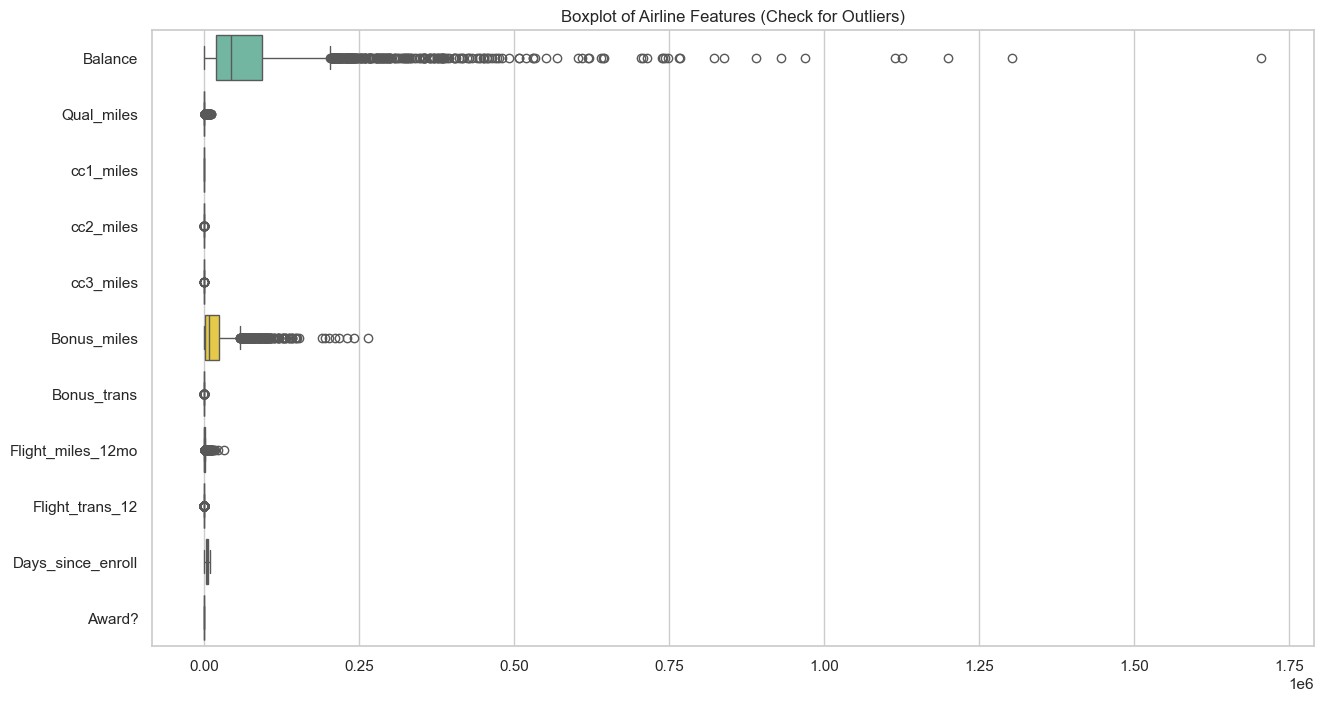

In [17]:
plt.figure(figsize=(15, 8))
# orient="h" makes it horizontal so column names are easier to read
sns.boxplot(data=df_cleaned, orient="h", palette="Set2")
plt.title("Boxplot of Airline Features (Check for Outliers)")
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/9 Clustering/Airlines graphs/Boxplot.png")
plt.show()

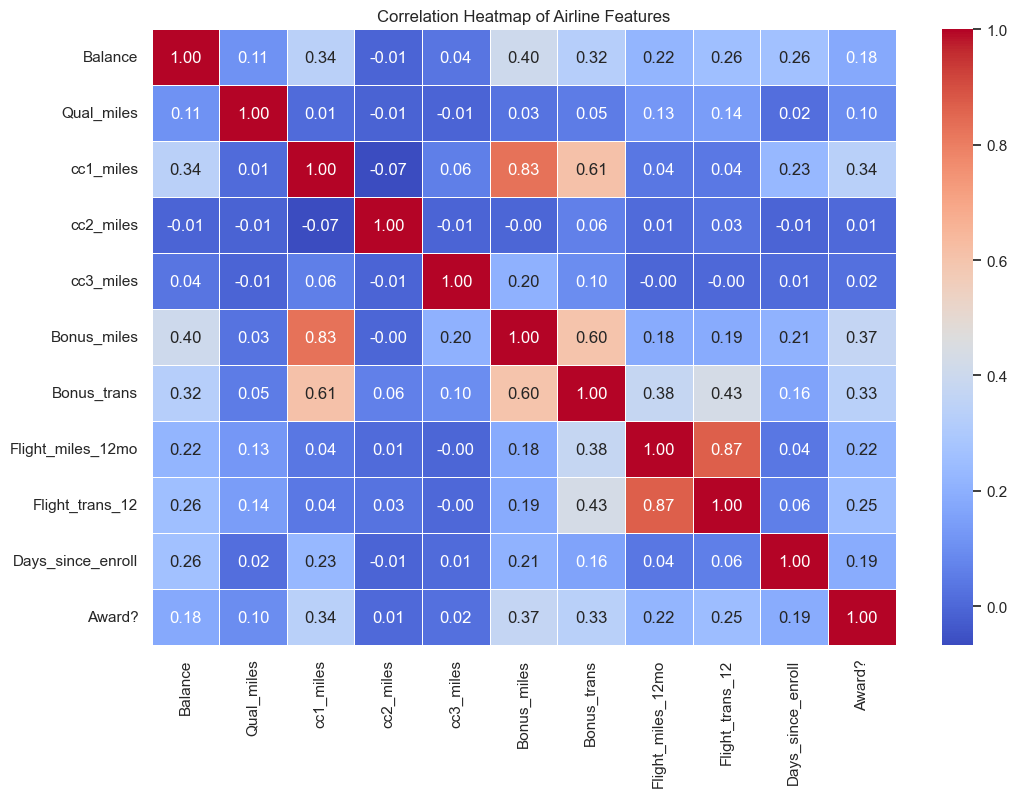

In [18]:
plt.figure(figsize=(12, 8))
# .corr() calculates the correlation between all numerical columns
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Airline Features")
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/9 Clustering/Airlines graphs/HeatMap.png")
plt.show()

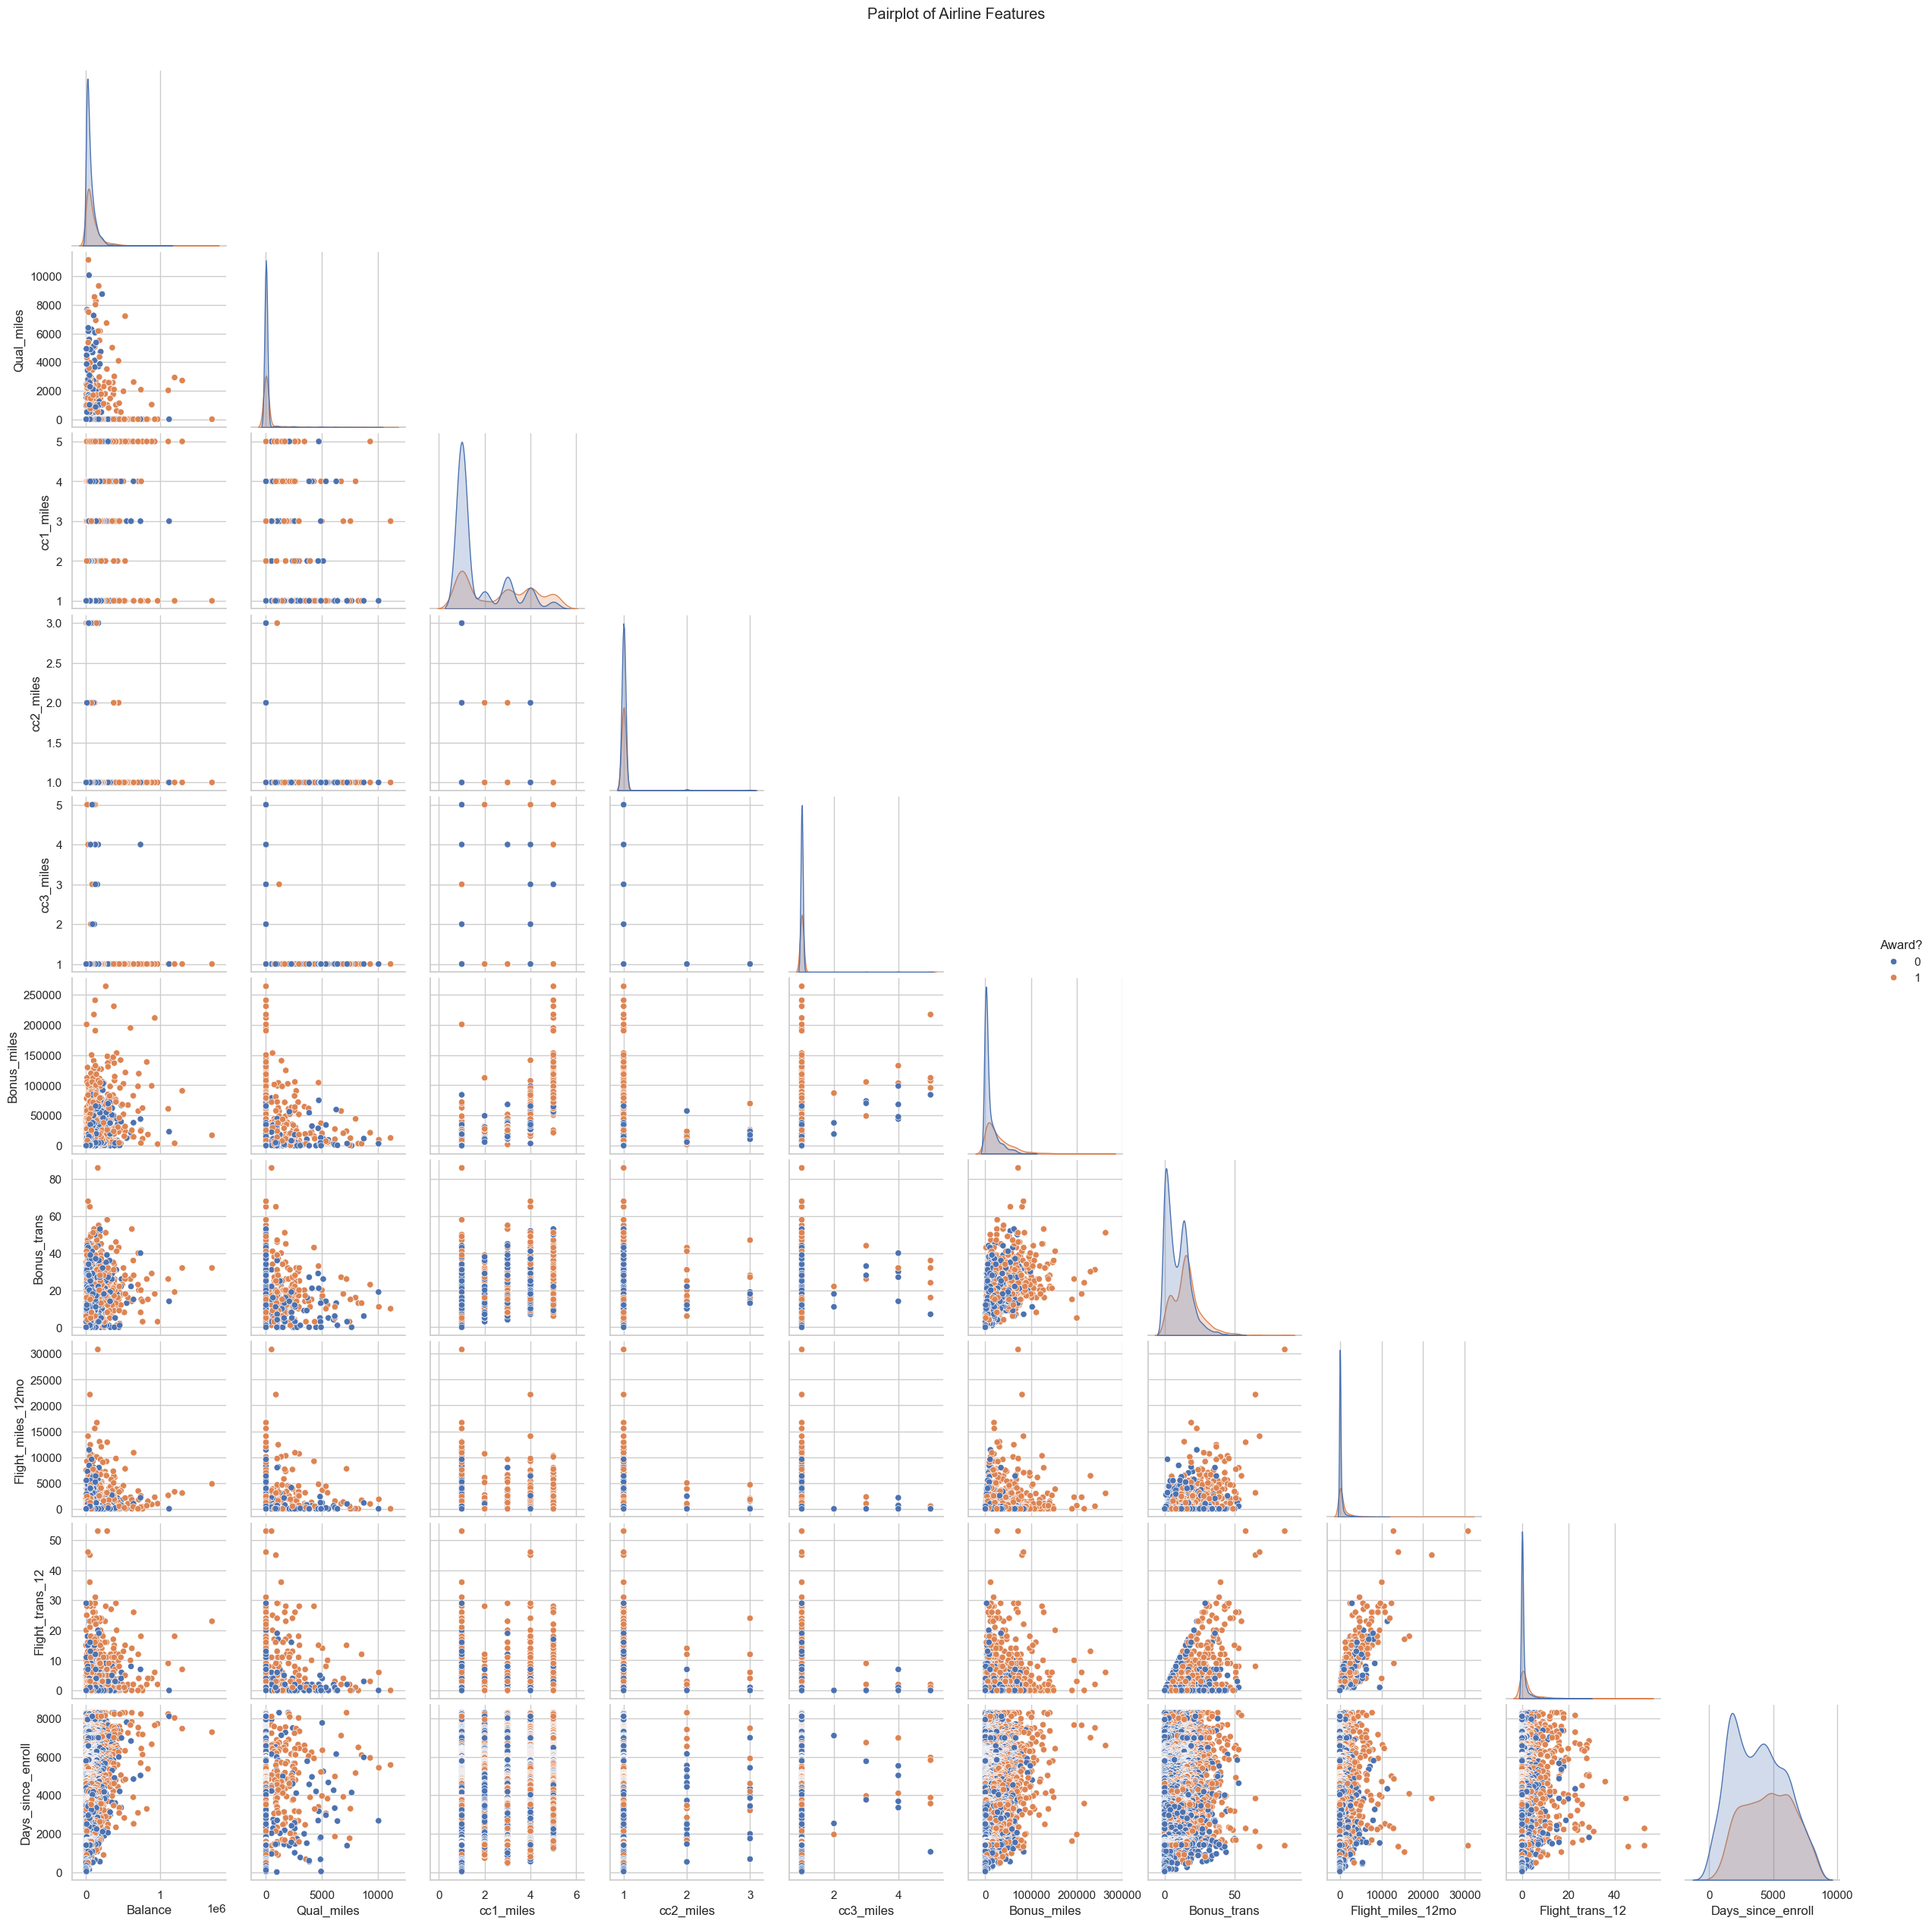

In [19]:
sns.pairplot(df_cleaned, hue='Award?', diag_kind='kde', corner=True)
plt.suptitle("Pairplot of Airline Features", y=1.02) # y=1.02 shifts title up slightly
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/9 Clustering/Airlines graphs/Pairplot.png")
plt.show()

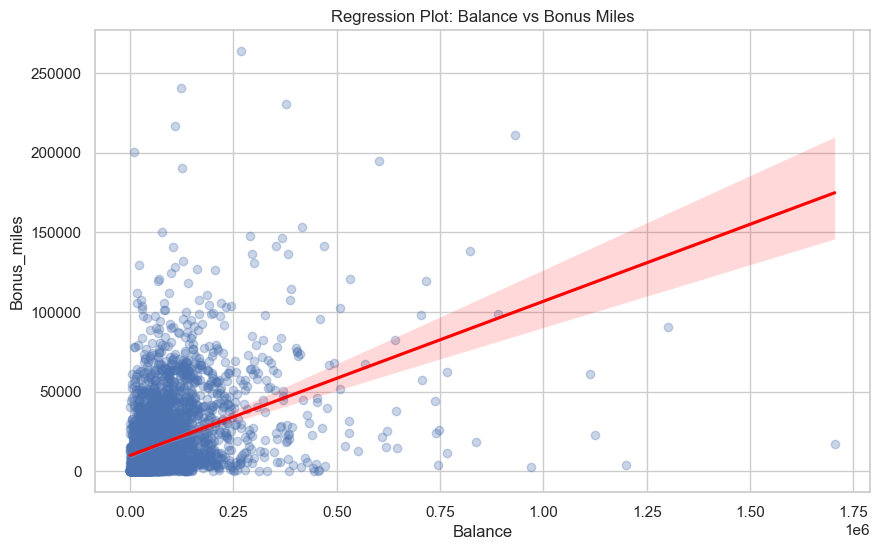

In [20]:
plt.figure(figsize=(10, 6))
# scatter_kws={'alpha':0.3} makes points slightly transparent to see density
sns.regplot(x='Balance', y='Bonus_miles', data=df_cleaned, 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Regression Plot: Balance vs Bonus Miles")
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/9 Clustering/Airlines graphs/Regression plot.png")
plt.show()

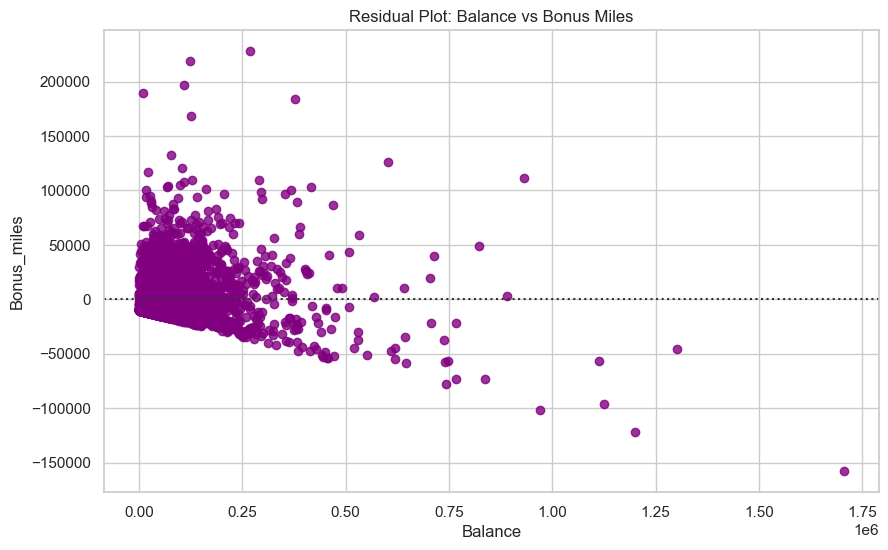

In [21]:
plt.figure(figsize=(10, 6))
sns.residplot(x='Balance', y='Bonus_miles', data=df_cleaned, color="purple")
plt.title("Residual Plot: Balance vs Bonus Miles")
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/9 Clustering/Airlines graphs/Residual plot.png")
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the cleaned data
scaled_df = scaler.fit_transform(df_cleaned)

# Convert back to a DataFrame to keep it organized (optional but helpful)
df_scaled = pd.DataFrame(scaled_df, columns=df_cleaned.columns)

print("Data has been standardized.")
df_scaled.head()

Data has been standardized.


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.451294,-0.186323,-0.769732,-0.098254,-0.062774,-0.702920,-1.104430,-0.328649,-0.362219,1.395235,-0.767072
1,-0.539605,-0.186323,-0.769732,-0.098254,-0.062774,-0.701223,-1.000286,-0.328649,-0.362219,1.379736,-0.767072
2,-0.320192,-0.186323,-0.769732,-0.098254,-0.062774,-0.539397,-0.791997,-0.328649,-0.362219,1.411702,-0.767072
3,-0.583944,-0.186323,-0.769732,-0.098254,-0.062774,-0.689421,-1.104430,-0.328649,-0.362219,1.371987,-0.767072
4,0.239483,-0.186323,1.409207,-0.098254,-0.062774,1.082876,1.499179,1.154721,0.692324,1.363754,1.303659


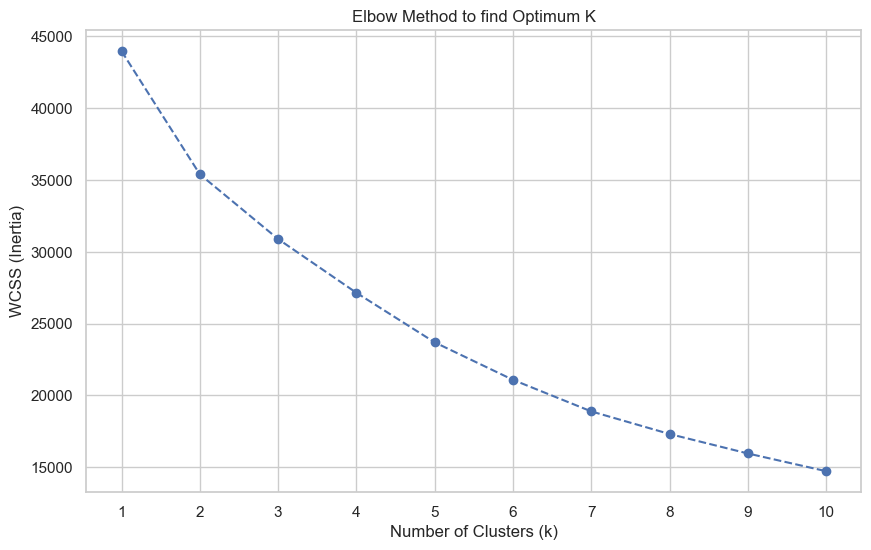

In [23]:
from sklearn.cluster import KMeans

wcss = []
# Testing K values from 1 to 11
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to find Optimum K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.show()

In [24]:
from sklearn.cluster import KMeans

# 1. Initialize K-Means with the optimum K (let's use 5)
clusters_new = KMeans(5, random_state=42, n_init=10)
clusters_new.fit(df_scaled)

# 2. Assign the cluster labels to our cleaned dataframe
df_cleaned['clusterid_Kmeans'] = clusters_new.labels_

# 3. Check how many passengers are in each group
print("Passenger count per cluster:")
print(df_cleaned['clusterid_Kmeans'].value_counts())

# 4. View the first few rows with the new labels
df_cleaned.head()

Passenger count per cluster:
clusterid_Kmeans
1    2500
0    1276
2     164
4      43
3      15
Name: count, dtype: int64


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,clusterid_Kmeans
0,28143,0,1,1,1,174,1,0,0,7000,0,1
1,19244,0,1,1,1,215,2,0,0,6968,0,1
2,41354,0,1,1,1,4123,4,0,0,7034,0,1
3,14776,0,1,1,1,500,1,0,0,6952,0,1
4,97752,0,4,1,1,43300,26,2077,4,6935,1,0


In [25]:
# Group by the cluster ID and find the average of all features
analysis = df_cleaned.groupby('clusterid_Kmeans').mean()
analysis

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
clusterid_Kmeans,,,,,,,,,,,
0,116600.339342,154.392633,3.700627,1.000000,1.001567,39131.264107,18.719436,333.050157,0.993730,4895.256270,0.645768
1,43756.981200,99.112800,1.221200,1.000000,1.000400,4572.811200,6.794000,198.298000,0.616400,3686.501600,0.200000
2,189778.103659,788.689024,2.189024,1.000000,1.000000,31452.060976,26.524390,5404.835366,15.640244,4671.030488,0.804878
3,138061.400000,78.800000,3.466667,1.000000,4.066667,93927.866667,28.066667,506.666667,1.600000,4613.866667,0.533333
4,68876.581395,23.255814,1.139535,2.348837,1.000000,14689.837209,17.534884,582.627907,2.209302,3968.930233,0.395349


#Key Observations:
Cluster 2 is your gold mine: They fly 10x more than Cluster 1. They aren't just spending on cards; they are actually in the air.

Cluster 1 is your biggest risk: They have low engagement and low loyalty. They might need a "re-engagement" campaign.

Cluster 3 is very niche: Notice that cc3_miles (Small Business card) is only high here. This is a specific group of business owners.

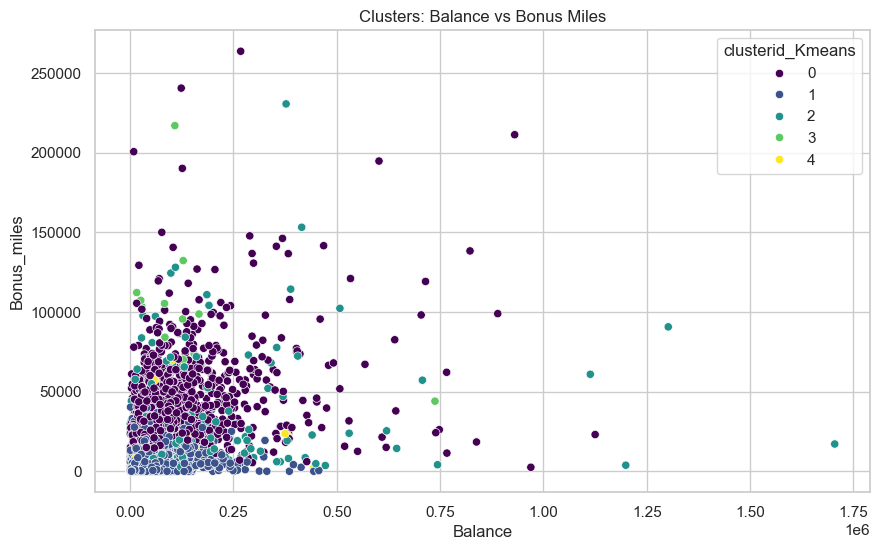

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='Balance', y='Bonus_miles', hue='clusterid_Kmeans', palette='viridis')
plt.title('Clusters: Balance vs Bonus Miles')
plt.show()

The Core Segments:

Cluster 1 (The Bulk - Lowest Value): This is your largest group. They have the lowest balances and rarely use credit cards for miles.
Action: Target with "First Flight" discounts to build loyalty.

Cluster 2 (The VIP Flyers): They have high balances and the highest actual flight activity.
Action: Priority service, lounge access, and "Elite Status" renewals.

Cluster 0 & 3 (The Card Loyalists): These people earn miles primarily through spending (CC1 and CC3).
Action: Partner with retail brands or credit card companies to offer double-point weekends.

Cluster 4 (The Rewards Users): Specifically high in CC2 miles.
Action: Specialized card-holder events or specific travel insurance perks.